# Предобработка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from IPython.display import clear_output

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, KFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import r2_score, mean_absolute_percentage_error, make_scorer
from google.colab import drive
drive.mount("/content/drive", force_remount=True)




import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/resultwithfeatures.csv')

In [3]:
df.head()

,Source,Smiles,Exp. Animal,Method of administration,LD50,LD50 (a.u.),Carcinogenicity,Carcinogenicity (a.u.),Hepatoxicity,Hepatoxicity (a.u.),...,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023,MorganFP_1024
0,ChEMBL,Br.Br.Cc1cc(-c2ccc(O)cc2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,300.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,ChEMBL,Br.Br.Cc1cc(-c2cccc(O)c2)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
2,ChEMBL,Br.Br.Cc1cc(-c2ccccc2O)nnc1NCCN1CCOCC1,mouse,intraperitoneal,200.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
3,ChEMBL,Br.CC(C)C(N)C(=O)NNc1nncc(-c2ccc(Cl)cc2)n1.O,mouse,intraperitoneal,178.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,1,0
4,ChEMBL,Br.CC(C)N(CCCOc1ccc(N/C(=N\c2ccccc2)c2ccccc2)c...,mouse,intraperitoneal,140.0,mg/kg,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0


## Предобработка данных

Удаляем столбцы и значения, которые точно будут лишними

In [4]:
print(f'Датасет исходный: {df.shape}')

df = df.drop_duplicates(subset = ['Smiles', 'Exp. Animal', 'Method of administration'])


df = df.drop(['Source', 'Smiles',
       'LD50 (a.u.)', 'Carcinogenicity', 'Carcinogenicity (a.u.)',
       'Hepatoxicity', 'Hepatoxicity (a.u.)', 'Eye_Corrosion',
       'Eye_Corrosion (a.u.)', 'Eye_Irritation', 'Eye_Irritation (a.u.)',
       'Mutagenicity', 'Mutagenicity (a.u.)', 'Respiratory_Toxicity',
       'Respiratory_Toxicity (a.u.)', 'LC50', 'LC50 (a.u.)', 'NOAEL',
       'NOAEL (a.u)'], axis = 1).reset_index(drop = True)


df = df.dropna(subset=['LD50'])

print(f'Датасет после удаления дубликатов, лишних записей и пропусков по таргету: {df.shape}')

Датасет исходный: (114757, 1422)
Датасет после удаления дубликатов, лишних записей и пропусков по таргету: (98512, 1403)


Сокращаем память датасета за счёт оптимизации типов данных.

In [5]:
print(f'Исходный размер памяти до преобразования типов: {df.memory_usage(deep=True).sum() / (1024 * 1024):.2f} МБ')

obj_cols = df.select_dtypes('object').columns
df[obj_cols] = df[obj_cols].astype('category')

fcols = df.select_dtypes('float').columns
icols = df.select_dtypes('integer').columns

df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

fcols = df.select_dtypes('float').columns
icols = df.select_dtypes('integer').columns

df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

print(f'Размер датасета после преобразования типов: {df.memory_usage(deep=True).sum() / (1024 * 1024):.2f} МБ')

Исходный размер памяти до преобразования типов: 1065.77 МБ
Размер датасета после преобразования типов: 194.57 МБ


In [6]:
df['LD50'].describe()

,LD50
count,9.851200e+04
mean,1.616472e+03
std,2.204321e+04
min,0.000000e+00
25%,1.000000e+02
50%,4.000000e+02
75%,1.000007e+03
max,2.500000e+06


In [7]:
Q10 = df['LD50'].quantile(0.10)
Q90 = df['LD50'].quantile(0.90)
IQR = Q90 - Q10

lower_bound = Q10 - 1.5 * IQR
upper_bound = Q90 + 1.5 * IQR

df = df[(df['LD50'] >= lower_bound) & (df['LD50'] <= upper_bound)]
df = df[df['LD50'] != 0]


threshold = 0.996
#удаляем столбцы, где 99.6% значений — это одно уникальное значение
def drop_constant_columns(df, threshold):
    to_drop = []  # Список столбцов для удаления
    for col in df.columns:
        # Рассчитываем долю самого частого значения
        max_freq = df[col].value_counts(normalize=True).max()
        if max_freq >= threshold:
            to_drop.append(col)
    return df.drop(columns=to_drop)

df_cleaned = drop_constant_columns(df, threshold)
df = df_cleaned.dropna()

print(f'Размерность датасета после работы с выбросами: {df.shape}')

Размерность датасета после работы с выбросами: (92494, 1382)


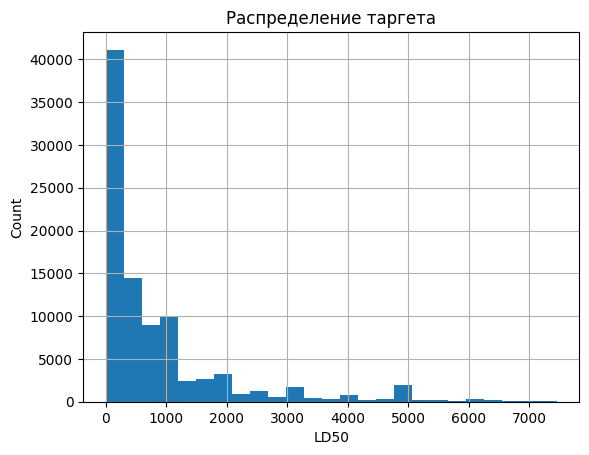

In [8]:
df['LD50'].hist(bins = 25)
plt.title('Распределение таргета')
plt.xlabel('LD50')
plt.ylabel('Count')
plt.show()

Мы видим, что распределение таргета имеет правостороннюю асимметрию. Решение - прологарифмировать, чтобы придать вид нормального распределения.

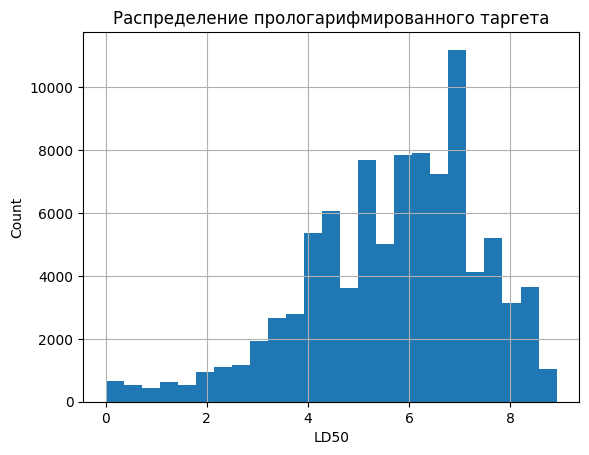

In [9]:
df['log_LD50'] = np.log1p(df['LD50'])  # Используем log1p для избежания проблем с нулями
df['log_LD50'].hist(bins = 25)
plt.title('Распределение прологарифмированного таргета')
plt.xlabel('LD50')
plt.ylabel('Count')
plt.show()

In [10]:
X = df.drop(columns=['LD50', 'log_LD50'])
y = df['log_LD50']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=123)

In [11]:
num_col = X.select_dtypes(include=['number']).columns.tolist()
cat_col = X.select_dtypes(include=['category']).columns.tolist()

X_train_cat = X_train[cat_col]
X_train_num = X_train[num_col]

X_test_cat = X_test[cat_col]
X_test_num = X_test[num_col]

In [12]:
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop = 'first')

X_train_encoded = OHE.fit_transform(X_train_cat)
X_test_encoded = OHE.transform(X_test_cat)

ohe_columns = OHE.get_feature_names_out(cat_col)
X_train_cat = pd.DataFrame(X_train_encoded, columns=ohe_columns, index=X_train.index)
X_test_cat = pd.DataFrame(X_test_encoded, columns=ohe_columns, index=X_test.index)

In [13]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col])
X_test_scaled = scaler.transform(X_test[num_col])

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col, index=X_test.index)


X_train = pd.concat([X_train_cat, X_train_scaled], axis=1)
X_test = pd.concat([X_test_cat, X_test_scaled], axis=1)

X_train.shape, X_test.shape

((73995, 1391), (18499, 1391))

# Нейросетевой подход обучения модели предсказания токсичности химических веществ

Идея подхода: подбор наилучшей архитектуры полносвязной нейронной сети с целью минимизации MAPE.

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, shuffle=True, random_state=42
)

Функция для нормализации таргета

In [16]:
def normalize(y):
    return (y - y_train.min()) / (y_train.max() - y_train.min())

def denormalize(y_norm):
    return y_norm * (y_train.max() - y_train.min()) + y_train.min()

Функция для расчёта MAPE с денормализацией и обратным приведением из логарифмирования.

In [17]:
def mape_metric(y_pred, y_true):
    y_pred = torch.expm1(y_pred)
    y_true = torch.expm1(y_true)

    return torch.mean(torch.abs(denormalize((y_true) - denormalize(y_pred)) / denormalize(y_true)))

In [18]:
def train_validate_test(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    val_loader,
    test_loader,
    num_epochs,
    verbose=True,
    device="cpu",
):


    train_losses, val_losses, test_losses = [], [], []
    train_metrics, val_metrics, test_metrics = [], [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(train_loader, desc=f"Training {epoch}/{num_epochs}")
            if verbose
            else train_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MAPE": metric_value})

        train_losses.append(running_loss / len(train_loader.dataset))
        train_metrics.append(running_metric / len(train_loader.dataset))

        # Validation
        model.eval()
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(val_loader, desc=f"Validating {epoch}/{num_epochs}")
            if verbose
            else val_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            with torch.no_grad():
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)

                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MAPE": metric_value})

        val_losses.append(running_loss / len(val_loader.dataset))
        val_metrics.append(running_metric / len(val_loader.dataset))

        # Test
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(test_loader, desc=f"Testing {epoch}/{num_epochs}")
            if verbose
            else test_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            with torch.no_grad():
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)
                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MAPE": metric_value})

        test_losses.append(running_loss / len(test_loader.dataset))
        test_metrics.append(running_metric / len(test_loader.dataset))

    return train_metrics[-1], val_metrics[-1], test_metrics[-1]

Первая нейросеть с 4-мя скрытыми слоями и базовыми параметрами.

In [19]:
input_size = X_train.shape[1]
lr = 1e-10
final_pred = 1
hidden_size = 256
num_epochs = 4
batch_size = 32

In [20]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype = torch.float32).to(device)


y_train_tensor = torch.tensor(normalize(y_train.values), dtype=torch.float32).reshape(-1, 1).to(device)
y_val_tensor = torch.tensor(normalize(y_val.values), dtype = torch.float32).reshape(-1, 1).to(device)
y_test_tensor = torch.tensor(normalize(y_test.values), dtype = torch.float32).reshape(-1, 1).to(device)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

In [21]:
class NN_v1(nn.Module):
    def __init__(self, hidden_size, input_size, final_pred):
        super(NN_v1, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout1 = nn.Dropout()

        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.dropout2 = nn.Dropout()

        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.bn3 = nn.BatchNorm1d(hidden_size)
        self.dropout3 = nn.Dropout()

        self.fc4 = nn.Linear(hidden_size, final_pred)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout1(out)

        out = self.fc2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout2(out)

        out = self.fc3(out)
        out = self.bn3(out)
        out = self.relu(out)
        out = self.dropout3(out)

        out = self.fc4(out)
        return out


model = NN_v1(hidden_size, input_size, final_pred).to(device)

In [22]:
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.MSELoss()

In [23]:
train_mape, val_mape, test_mape = train_validate_test(model, optimizer, criterion, mape_metric, train_loader, val_loader, test_loader, num_epochs)

Training 1/4:   0%|          | 0/1850 [00:00<?, ?it/s]

Validating 1/4:   0%|          | 0/463 [00:00<?, ?it/s]

Testing 1/4:   0%|          | 0/579 [00:00<?, ?it/s]

Training 2/4:   0%|          | 0/1850 [00:00<?, ?it/s]

Validating 2/4:   0%|          | 0/463 [00:00<?, ?it/s]

...

Validating 3/4:   0%|          | 0/463 [00:00<?, ?it/s]

Testing 3/4:   0%|          | 0/579 [00:00<?, ?it/s]

Training 4/4:   0%|          | 0/1850 [00:00<?, ?it/s]

Validating 4/4:   0%|          | 0/463 [00:00<?, ?it/s]

Testing 4/4:   0%|          | 0/579 [00:00<?, ?it/s]

In [24]:
print(f"MAPE на тренировочной выборке: {train_mape:.2f}%")
print(f"MAPE на валидационной выборке: {val_mape:.2f}%")
print(f"MAPE на тестовой выборке: {test_mape:.2f}%")

MAPE на тренировочной выборке: 28.53%
MAPE на валидационной выборке: 29.38%
MAPE на тестовой выборке: 36.56%


Проценты здесь и ниже в коде лишние, на самом деле - это доля, т.е. в данном случае, >100%

Попробуем увеличить число слоёв до 5, также изменим архитектуру нашей сети

In [85]:
input_size = X_train.shape[1]
lr = 3e-4
final_pred = 1
hidden_size = 512
num_epochs = 8
betas=(0.9, 0.999)
eps=1e-08

In [34]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype = torch.float32).to(device)


y_train_tensor = torch.tensor(normalize(y_train.values), dtype=torch.float32).reshape(-1, 1).to(device)
y_val_tensor = torch.tensor(normalize(y_val.values), dtype = torch.float32).reshape(-1, 1).to(device)
y_test_tensor = torch.tensor(normalize(y_test.values), dtype = torch.float32).reshape(-1, 1).to(device)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

In [35]:
class NN_v2(nn.Module):
    def __init__(self, hidden_size, input_size, final_pred):
        super(NN_v2, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout1 = nn.Dropout()

        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.dropout2 = nn.Dropout(p = 0.3)

        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.bn3 = nn.BatchNorm1d(hidden_size)
        self.dropout3 = nn.Dropout(p = 0.2)

        self.fc4 = nn.Linear(hidden_size, hidden_size)
        self.bn4 = nn.BatchNorm1d(hidden_size)
        self.dropout4 = nn.Dropout(p = 0.4)

        self.fc5 = nn.Linear(hidden_size, final_pred)
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01) # leakyReLU вместо "классического" ReLU

    def forward(self, x):
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.leaky_relu(out)
        out = self.dropout1(out)

        out = self.fc2(out)
        out = self.bn2(out)
        out = self.leaky_relu(out)
        out = self.dropout2(out)

        out = self.fc3(out)
        out = self.bn3(out)
        out = self.leaky_relu(out)
        out = self.dropout3(out)

        out = self.fc4(out)
        out = self.bn4(out)
        out = self.leaky_relu(out)
        out = self.dropout4(out)

        out = self.fc5(out) # увеличили число слоёв
        return out

model_2 = NN_v2(hidden_size, input_size, final_pred).to(device)

In [36]:
optimizer = torch.optim.Adam(model_2.parameters(), eps = eps, betas = betas, lr=lr) # используем оптимизатор Adam вместо SGD регрессора
criterion = nn.MSELoss()

In [37]:
train_mape, val_mape, test_mape = train_validate_test(model_2, optimizer, criterion, mape_metric, train_loader, val_loader, test_loader, num_epochs)

Training 1/8:   0%|          | 0/1850 [00:00<?, ?it/s]

Validating 1/8:   0%|          | 0/463 [00:00<?, ?it/s]

Testing 1/8:   0%|          | 0/579 [00:00<?, ?it/s]

Training 2/8:   0%|          | 0/1850 [00:00<?, ?it/s]

Validating 2/8:   0%|          | 0/463 [00:00<?, ?it/s]

...

Validating 7/8:   0%|          | 0/463 [00:00<?, ?it/s]

Testing 7/8:   0%|          | 0/579 [00:00<?, ?it/s]

Training 8/8:   0%|          | 0/1850 [00:00<?, ?it/s]

Validating 8/8:   0%|          | 0/463 [00:00<?, ?it/s]

Testing 8/8:   0%|          | 0/579 [00:00<?, ?it/s]

In [38]:
print(f"MAPE на тренировочной выборке: {train_mape:.2f}")
print(f"MAPE на валидационной выборке: {val_mape:.2f}")
print(f"MAPE на тестовой выборке: {test_mape:.2f}")

MAPE на тренировочной выборке: 21.94%
MAPE на валидационной выборке: 24.00%
MAPE на тестовой выборке: 31.51%


В третьей реализации попробуем более продвинутые функции активации и AdamW с гиперпараметрами.

In [55]:
input_size = X_train.shape[1]
lr = 3e-4
final_pred = 1
hidden_size = 512
num_epochs = 8
betas=(0.9, 0.999)
eps=1e-08

In [56]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype = torch.float32).to(device)


y_train_tensor = torch.tensor(normalize(y_train.values), dtype=torch.float32).reshape(-1, 1).to(device)
y_val_tensor = torch.tensor(normalize(y_val.values), dtype = torch.float32).reshape(-1, 1).to(device)
y_test_tensor = torch.tensor(normalize(y_test.values), dtype = torch.float32).reshape(-1, 1).to(device)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

In [57]:
class NN_v3(nn.Module):
    def __init__(self, input_size, hidden_size, final_pred):
        super(NN_v3, self).__init__()
        self.bn_input = nn.BatchNorm1d(input_size)
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.act1 = nn.GELU()
        self.do1 = nn.AlphaDropout(0.15)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn2 = nn.BatchNorm1d(hidden_size // 2)
        self.act2 = nn.Mish() # Mish = x tanh(softplus(x)). - более плавная по сравнению с softplus
        self.do2 = nn.Dropout(0.20)
        self.fc3 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.bn3 = nn.BatchNorm1d(hidden_size // 4)
        self.act3 = nn.LeakyReLU(0.01)
        self.do3 = nn.Dropout(0.25)
        self.fc4 = nn.Linear(hidden_size // 4, hidden_size // 8)
        self.act4 = nn.GELU() # GeLU - продвинутая вариация функции активации ReLU
        self.do4 = nn.Dropout(0.20)
        self.fc5 = nn.Linear(hidden_size // 8, final_pred)

    def forward(self, x):
        x = self.bn_input(x)

        x = self.fc1(x)
        x = self.act1(x)
        x = self.do1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.do2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.do3(x)

        x = self.fc4(x)
        x = self.act4(x)
        x = self.do4(x)

        out = self.fc5(x)
        return out


model_3 = NN_v3(input_size, hidden_size, final_pred).to(device)

In [58]:
optimizer = torch.optim.AdamW(model_3.parameters(), eps = eps, betas = betas, lr=lr, weight_decay = 1e-6) # добавили weight_decay - аналог L2 регуляризации из классического ML
criterion = nn.MSELoss()

In [59]:
train_mape, val_mape, test_mape = train_validate_test(model_3, optimizer, criterion, mape_metric, train_loader, val_loader, test_loader, num_epochs)

Training 1/8:   0%|          | 0/1850 [00:00<?, ?it/s]

Validating 1/8:   0%|          | 0/463 [00:00<?, ?it/s]

Testing 1/8:   0%|          | 0/579 [00:00<?, ?it/s]

Training 2/8:   0%|          | 0/1850 [00:00<?, ?it/s]

Validating 2/8:   0%|          | 0/463 [00:00<?, ?it/s]

...

Validating 7/8:   0%|          | 0/463 [00:00<?, ?it/s]

Testing 7/8:   0%|          | 0/579 [00:00<?, ?it/s]

Training 8/8:   0%|          | 0/1850 [00:00<?, ?it/s]

Validating 8/8:   0%|          | 0/463 [00:00<?, ?it/s]

Testing 8/8:   0%|          | 0/579 [00:00<?, ?it/s]

In [61]:
print(f"MAPE на тренировочной выборке: {train_mape:.2f}")
print(f"MAPE на валидационной выборке: {val_mape:.2f}")
print(f"MAPE на тестовой выборке: {test_mape:.2f}")

MAPE на тренировочной выборке: 8.30%
MAPE на валидационной выборке: 7.71%
MAPE на тестовой выборке: 9.95%


 Попробуем сделать нейросеть с 6-ю слоями

In [86]:
input_size = X_train.shape[1]
lr = 3e-4
final_pred = 1
hidden_size = 512
num_epochs = 2
betas=(0.9, 0.999)
eps=1e-08
batch_size = 16

In [87]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test.values, dtype = torch.float32).to(device)


y_train_tensor = torch.tensor(normalize(y_train.values), dtype=torch.float32).reshape(-1, 1).to(device)
y_val_tensor = torch.tensor(normalize(y_val.values), dtype = torch.float32).reshape(-1, 1).to(device)
y_test_tensor = torch.tensor(normalize(y_test.values), dtype = torch.float32).reshape(-1, 1).to(device)


train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset = test_dataset, batch_size = batch_size, shuffle = False)

In [88]:
class NN_v4(nn.Module):
    def __init__(self, input_size, hidden_size, final_pred):
        super(NN_v4, self).__init__()
        self.bn_input = nn.BatchNorm1d(input_size)

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.act1 = nn.GELU()
        self.do1 = nn.AlphaDropout(0.15)


        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        self.act2 = nn.Mish()
        self.do2 = nn.Dropout(0.20)


        self.fc3 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn3 = nn.BatchNorm1d(hidden_size // 2)
        self.act3 = nn.LeakyReLU(0.01)
        self.do3 = nn.Dropout(0.25)


        self.fc4 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.act4 = nn.GELU()
        self.do4 = nn.Dropout(0.20)


        self.fc5 = nn.Linear(hidden_size // 4, hidden_size // 4)
        self.bn5 = nn.BatchNorm1d(hidden_size // 4)
        self.act5 = nn.Mish() # Mish = x tanh(softplus(x)). - более плавная по сравнению с softplus
        self.do5 = nn.Dropout(0.25)

        self.fc6 = nn.Linear(hidden_size // 4, hidden_size // 8)
        self.act6 = nn.GELU()
        self.do6 = nn.Dropout(0.20)

        self.fc_final = nn.Linear(hidden_size // 8, final_pred)

    def forward(self, x):
        x = self.bn_input(x)

        x = self.fc1(x)
        x = self.act1(x)
        x = self.do1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.do2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.do3(x)

        x = self.fc4(x)
        x = self.act4(x)
        x = self.do4(x)

        x = self.fc5(x)
        x = self.bn5(x)
        x = self.act5(x)
        x = self.do5(x)

        x = self.fc6(x)
        x = self.act6(x)
        x = self.do6(x)

        out = self.fc_final(x)
        return out


model_4 = NN_v4(input_size, hidden_size, final_pred).to(device)

In [89]:
optimizer = torch.optim.AdamW(model_4.parameters(), eps = eps, betas = betas, lr=lr, weight_decay = 1e-6) # добавили weight_decay - аналог L2 регуляризации из классического ML
criterion = nn.MSELoss()

In [90]:
train_mape, val_mape, test_mape = train_validate_test(model_4, optimizer, criterion, mape_metric, train_loader, val_loader, test_loader, num_epochs)

Training 1/2:   0%|          | 0/3700 [00:00<?, ?it/s]

Validating 1/2:   0%|          | 0/925 [00:00<?, ?it/s]

Testing 1/2:   0%|          | 0/1157 [00:00<?, ?it/s]

Training 2/2:   0%|          | 0/3700 [00:00<?, ?it/s]

Validating 2/2:   0%|          | 0/925 [00:00<?, ?it/s]

Testing 2/2:   0%|          | 0/1157 [00:00<?, ?it/s]

In [91]:
print(f"MAPE на тренировочной выборке: {train_mape:.2f}")
print(f"MAPE на валидационной выборке: {val_mape:.2f}")
print(f"MAPE на тестовой выборке: {test_mape:.2f}")

MAPE на тренировочной выборке: 25.57
MAPE на валидационной выборке: 27.97
MAPE на тестовой выборке: 37.98


In [53]:
lr_lst = [1e-3, 3e-4, 1e-5, 1e-6, 1e-8, 1e-10]
weight_decay = np.logspace(-3, -6, 4)
weight_decay_full = np.insert(weight_decay, 0, 0)

Вывод: не удалось подобрать архитектуру для разумно качественного MAPE.